# 앙상블 모델 (v7) — v3 CNN + v6 CatBoost 가중 소프트 보팅

## 전략
- **v3 (Multi-scale CNN)**: 전체 Macro F1 최고 (0.871) → 전반적인 분류 강점
- **v6 (CatBoost)**: Infiltration F1 최고 (0.583) → 내부 침투 탐지 강점
- **방법**: 두 모델의 소프트맥스 확률을 가중 평균 후 argmax

```
final_prob[i] = w_cnn * prob_v3[i] + w_cat * prob_v6[i]
prediction    = argmax(final_prob)
```

## 가중치 탐색 방법
Validation Set으로 w_cnn : w_cat 비율을 그리드 서치하여 최적 가중치 선택

## 1. 라이브러리 임포트

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from catboost import CatBoostClassifier

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

SEED   = 42
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
np.random.seed(SEED)

print(f'Device: {DEVICE}')

Device: cpu


## 2. 데이터 로드 & 분할

In [3]:
BASE_DIR   = os.path.dirname(os.path.abspath('__file__'))
OUTPUT_DIR = os.path.join(BASE_DIR, 'processed')
MODEL_DIR  = os.path.join(BASE_DIR, 'models')

X = np.load(os.path.join(OUTPUT_DIR, 'X.npy'))
y = np.load(os.path.join(OUTPUT_DIR, 'y.npy'))

with open(os.path.join(OUTPUT_DIR, 'label_mapping.json'), encoding='utf-8') as f:
    label_mapping = json.load(f)

idx2label   = {v: k for k, v in label_mapping.items()}
class_names = [idx2label[i] for i in range(len(idx2label))]
num_classes = len(class_names)

# v3, v6와 동일한 분할 (SEED=42)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=SEED, stratify=y)
X_val,   X_test, y_val,   y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp)

print(f'Val  : {X_val.shape[0]:,}')
print(f'Test : {X_test.shape[0]:,}')

Val  : 349,637
Test : 349,638


## 3. v3 모델 정의 & 로드

In [4]:
class IDSDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long) if y is not None else None
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return (self.X[idx], self.y[idx]) if self.y is not None else self.X[idx]


class CNN1D_v3(nn.Module):
    def __init__(self, num_features, num_classes, dropout=0.3):
        super().__init__()
        self.conv1_k1 = nn.Conv1d(1, 32, kernel_size=1)
        self.conv1_k3 = nn.Conv1d(1, 32, kernel_size=3, padding=1)
        self.conv1_k5 = nn.Conv1d(1, 32, kernel_size=5, padding=2)
        self.bn1      = nn.BatchNorm1d(96)
        self.pool1    = nn.MaxPool1d(2)

        self.conv2  = nn.Conv1d(96, 128, kernel_size=3, padding=1)
        self.bn2    = nn.BatchNorm1d(128)
        self.conv2b = nn.Conv1d(128, 128, kernel_size=3, padding=1)
        self.bn2b   = nn.BatchNorm1d(128)
        self.skip2  = nn.Conv1d(96, 128, kernel_size=1)
        self.pool2  = nn.MaxPool1d(2)

        self.conv3      = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn3        = nn.BatchNorm1d(256)
        self.se_fc1     = nn.Linear(256, 64)
        self.se_fc2     = nn.Linear(64, 256)
        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        x = torch.cat([self.conv1_k1(x), self.conv1_k3(x), self.conv1_k5(x)], dim=1)
        x = self.pool1(torch.relu(self.bn1(x)))

        identity = self.skip2(x)
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.bn2b(self.conv2b(x))
        x = self.pool2(torch.relu(x + identity))

        x = torch.relu(self.bn3(self.conv3(x)))
        se = self.global_pool(x).squeeze(-1)
        se = torch.relu(self.se_fc1(se))
        se = torch.sigmoid(self.se_fc2(se)).unsqueeze(-1)
        x  = x * se

        x = self.global_pool(x)
        return self.classifier(x)


cnn_model = CNN1D_v3(num_features=70, num_classes=num_classes).to(DEVICE)
cnn_model.load_state_dict(
    torch.load(os.path.join(MODEL_DIR, 'best_model_v3.pt'), map_location=DEVICE, weights_only=True)
)
cnn_model.eval()
print('v3 CNN 모델 로드 완료')

v3 CNN 모델 로드 완료


## 4. v6 CatBoost 모델 로드

In [5]:
cb_model = CatBoostClassifier()
cb_model.load_model(os.path.join(MODEL_DIR, 'best_model_v6_catboost.cbm'))
print('v6 CatBoost 모델 로드 완료')

v6 CatBoost 모델 로드 완료


## 5. 확률 추출 함수

- v3: logits → softmax → 확률 벡터 (7개)
- v6: predict_proba() → 확률 벡터 (7개)

In [6]:
def get_cnn_proba(model, X_data, batch_size=1024):
    """v3 CNN → softmax 확률 반환 (N, 7)"""
    loader = DataLoader(
        IDSDataset(X_data),
        batch_size=batch_size, shuffle=False, num_workers=0
    )
    all_proba = []
    with torch.no_grad():
        for X_batch in loader:
            logits = model(X_batch.to(DEVICE))
            proba  = torch.softmax(logits, dim=1).cpu().numpy()
            all_proba.append(proba)
    return np.vstack(all_proba)  # (N, 7)


def get_cat_proba(model, X_data):
    """v6 CatBoost → 확률 반환 (N, 7)"""
    return model.predict_proba(X_data)  # (N, 7)


print('확률 추출 함수 정의 완료')
print('Validation set 확률 추출 중...')

val_proba_cnn = get_cnn_proba(cnn_model, X_val)
val_proba_cat = get_cat_proba(cb_model,  X_val)

print(f'CNN  확률 shape: {val_proba_cnn.shape}')
print(f'CatBoost 확률 shape: {val_proba_cat.shape}')

확률 추출 함수 정의 완료
Validation set 확률 추출 중...
CNN  확률 shape: (349637, 7)
CatBoost 확률 shape: (349637, 7)


## 6. 최적 가중치 탐색 (Grid Search on Validation Set)

w_cnn + w_cat = 1.0 조건에서 Infiltration F1과 Macro F1을 동시에 최대화하는 w 탐색

In [7]:
INFILTRATION_IDX = class_names.index('Infiltration')

results = []
weights = np.arange(0.0, 1.05, 0.05)  # w_cnn: 0.0 ~ 1.0

for w_cnn in weights:
    w_cat    = 1.0 - w_cnn
    combined = w_cnn * val_proba_cnn + w_cat * val_proba_cat
    preds    = combined.argmax(axis=1)

    macro_f1       = f1_score(y_val, preds, average='macro', zero_division=0)
    infiltration_f1 = f1_score(y_val, preds, labels=[INFILTRATION_IDX],
                               average='macro', zero_division=0)
    accuracy = (preds == y_val).mean()

    results.append({
        'w_cnn': round(w_cnn, 2),
        'w_cat': round(w_cat, 2),
        'macro_f1': macro_f1,
        'infiltration_f1': infiltration_f1,
        'accuracy': accuracy,
    })

# 결과 출력
print(f'{"w_cnn":>6} {"w_cat":>6} {"Accuracy":>10} {"Infiltration F1":>17} {"Macro F1":>10}')
print('-' * 58)
for r in results:
    print(f"{r['w_cnn']:>6.2f} {r['w_cat']:>6.2f} "
          f"{r['accuracy']:>10.4f} {r['infiltration_f1']:>17.4f} {r['macro_f1']:>10.4f}")

 w_cnn  w_cat   Accuracy   Infiltration F1   Macro F1
----------------------------------------------------------
  0.00   1.00     0.8906            0.5824     0.8373
  0.05   0.95     0.8928            0.5843     0.8398
  0.10   0.90     0.8955            0.5867     0.8424
  0.15   0.85     0.8979            0.5890     0.8441
  0.20   0.80     0.9001            0.5905     0.8467
  0.25   0.75     0.9020            0.5908     0.8499
  0.30   0.70     0.9042            0.5917     0.8529
  0.35   0.65     0.9056            0.5919     0.8548
  0.40   0.60     0.9072            0.5914     0.8570
  0.45   0.55     0.9084            0.5893     0.8588
  0.50   0.50     0.9092            0.5863     0.8611
  0.55   0.45     0.9099            0.5815     0.8664
  0.60   0.40     0.9102            0.5769     0.8669
  0.65   0.35     0.9103            0.5721     0.8683
  0.70   0.30     0.9099            0.5654     0.8710
  0.75   0.25     0.9092            0.5530     0.8719
  0.80   0.20     0.907

## 7. 최적 가중치 시각화

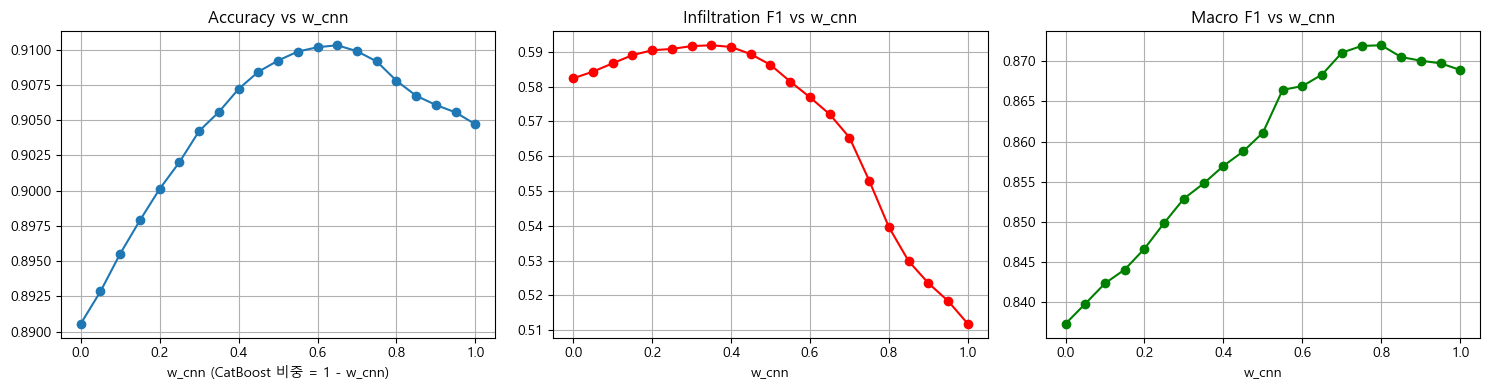


Macro F1 최대화 → w_cnn=0.80, w_cat=0.20  (Macro F1=0.8720)
Infiltration F1 최대화 → w_cnn=0.35, w_cat=0.65  (Infiltration F1=0.5919)


In [8]:
import pandas as pd
df = pd.DataFrame(results)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(df['w_cnn'], df['accuracy'], marker='o')
axes[0].set_title('Accuracy vs w_cnn')
axes[0].set_xlabel('w_cnn (CatBoost 비중 = 1 - w_cnn)')
axes[0].grid(True)

axes[1].plot(df['w_cnn'], df['infiltration_f1'], marker='o', color='red')
axes[1].set_title('Infiltration F1 vs w_cnn')
axes[1].set_xlabel('w_cnn')
axes[1].grid(True)

axes[2].plot(df['w_cnn'], df['macro_f1'], marker='o', color='green')
axes[2].set_title('Macro F1 vs w_cnn')
axes[2].set_xlabel('w_cnn')
axes[2].grid(True)

plt.tight_layout()
plt.show()

# 최적 가중치 출력
best_macro = df.loc[df['macro_f1'].idxmax()]
best_infil = df.loc[df['infiltration_f1'].idxmax()]
print(f'\nMacro F1 최대화 → w_cnn={best_macro["w_cnn"]:.2f}, w_cat={best_macro["w_cat"]:.2f}  (Macro F1={best_macro["macro_f1"]:.4f})')
print(f'Infiltration F1 최대화 → w_cnn={best_infil["w_cnn"]:.2f}, w_cat={best_infil["w_cat"]:.2f}  (Infiltration F1={best_infil["infiltration_f1"]:.4f})')

## 8. 최종 앙상블 평가 (Test Set)

- Macro F1 최대화를 원하면 → best_macro의 w_cnn
- Infiltration 탐지 극대화를 원하면 → best_infil의 w_cnn
- IPS 운영 목적이므로 **Infiltration F1과 Accuracy의 균형점**

In [12]:
W_CNN = 0.35
W_CAT = 1.0 - W_CNN

print(f'최종 가중치: CNN={W_CNN:.2f}, CatBoost={W_CAT:.2f}')
print('Test set 확률 추출 중...')

test_proba_cnn = get_cnn_proba(cnn_model, X_test)
test_proba_cat = get_cat_proba(cb_model,  X_test)

combined_proba = W_CNN * test_proba_cnn + W_CAT * test_proba_cat
y_pred_ensemble = combined_proba.argmax(axis=1)

print('\n=== Classification Report (v7: CNN v3 + CatBoost v6 앙상블) ===')
print(classification_report(y_test, y_pred_ensemble, target_names=class_names, digits=4))

최종 가중치: CNN=0.35, CatBoost=0.65
Test set 확률 추출 중...

=== Classification Report (v7: CNN v3 + CatBoost v6 앙상블) ===
               precision    recall  f1-score   support

       Benign     0.8800    0.8227    0.8504     75000
          Bot     0.9997    0.9999    0.9998     42929
  Brute Force     0.8604    0.9579    0.9066     57269
         DDoS     0.9993    0.9999    0.9996     75000
          DoS     0.9659    0.8816    0.9218     75000
 Infiltration     0.5463    0.6536    0.5952     24290
SQL Injection     0.5597    1.0000    0.7177       150

     accuracy                         0.9056    349638
    macro avg     0.8302    0.9022    0.8559    349638
 weighted avg     0.9122    0.9056    0.9075    349638



## 9. 단일 모델 vs 앙상블 비교

In [13]:
# v3 단독 예측
y_pred_v3 = test_proba_cnn.argmax(axis=1)
# v6 단독 예측
y_pred_v6 = test_proba_cat.argmax(axis=1)

def get_metrics(y_true, y_pred, label):
    infil_f1  = f1_score(y_true, y_pred, labels=[INFILTRATION_IDX], average='macro', zero_division=0)
    macro_f1  = f1_score(y_true, y_pred, average='macro', zero_division=0)
    accuracy  = (y_pred == y_true).mean()
    print(f'{label:<30} Accuracy={accuracy:.4f}  Infiltration F1={infil_f1:.4f}  Macro F1={macro_f1:.4f}')

print('모델별 최종 성능 비교 (Test Set)')
print('=' * 80)
get_metrics(y_test, y_pred_v3,       'v3 CNN (단독)')
get_metrics(y_test, y_pred_v6,       'v6 CatBoost (단독)')
get_metrics(y_test, y_pred_ensemble, f'v7 앙상블 (CNN={W_CNN:.2f} + Cat={W_CAT:.2f})')

모델별 최종 성능 비교 (Test Set)
v3 CNN (단독)                    Accuracy=0.9043  Infiltration F1=0.5120  Macro F1=0.8711
v6 CatBoost (단독)               Accuracy=0.8903  Infiltration F1=0.5832  Macro F1=0.8381
v7 앙상블 (CNN=0.35 + Cat=0.65)   Accuracy=0.9056  Infiltration F1=0.5952  Macro F1=0.8559


## 10. Confusion Matrix (앙상블)

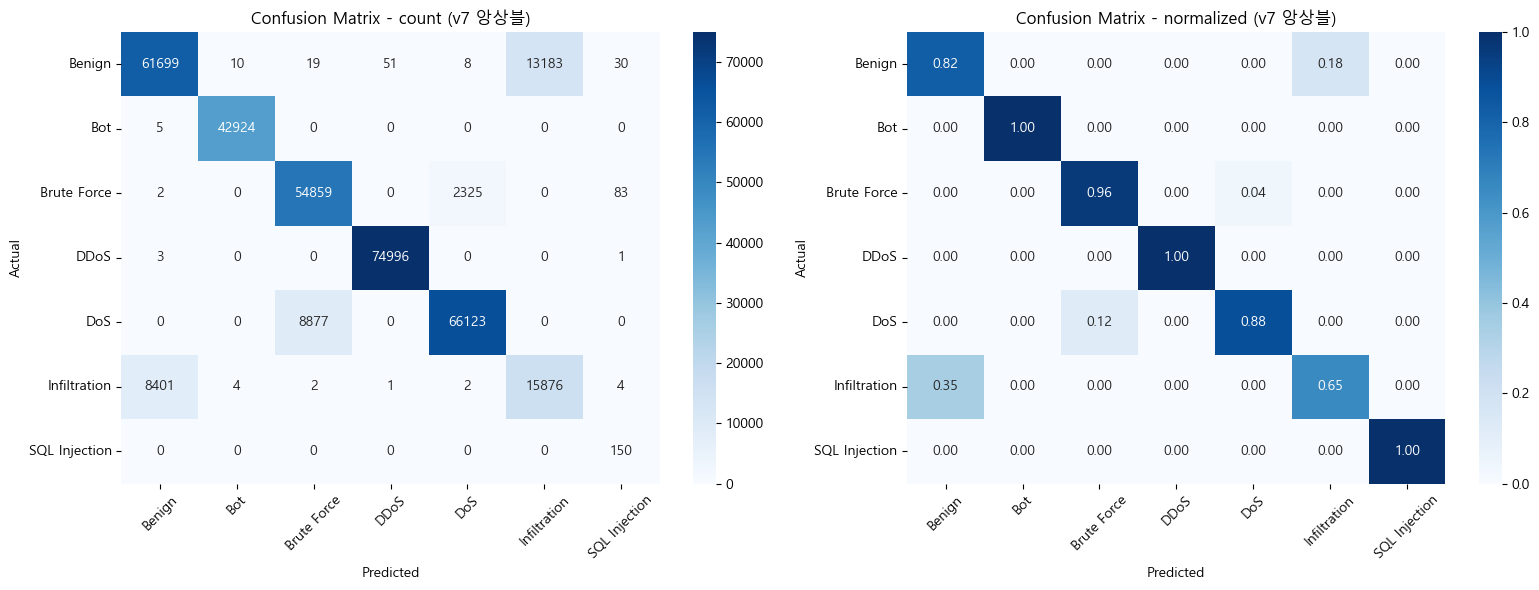

In [14]:
cm      = confusion_matrix(y_test, y_pred_ensemble)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - count (v7 앙상블)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix - normalized (v7 앙상블)')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()